# Supermarket Sales Analysis

## Objective
Analyze supermarket sales data to identify sales trends, customer behavior, and profitable product categories.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from google.colab import files

uploaded = files.upload()

Saving SuperMarket Analysis.csv to SuperMarket Analysis (1).csv


In [5]:
df = pd.read_csv("SuperMarket Analysis.csv")

In [6]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [7]:
df.shape

(1000, 17)

In [8]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [10]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


In [11]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

In [13]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df["Date"]

,Date
0,1/5/2019
1,3/8/2019
2,3/3/2019
3,1/27/2019
4,2/8/2019
...,...
995,1/29/2019
996,3/2/2019
997,2/9/2019
998,2/22/2019


In [16]:
df["Date"] = pd.to_datetime(df["Date"])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

In [18]:
df["Month"] = df["Date"].dt.month_name()

In [19]:
df[["Date", "Month"]].head()

,Date,Month
0,2019-01-05,January
1,2019-03-08,March
2,2019-03-03,March
3,2019-01-27,January
4,2019-02-08,February


In [20]:
df["Day"] = df["Date"].dt.day_name()

In [21]:
df[["Date", "Day"]].head()

,Date,Day
0,2019-01-05,Saturday
1,2019-03-08,Friday
2,2019-03-03,Sunday
3,2019-01-27,Sunday
4,2019-02-08,Friday


In [22]:
df.to_csv("SupermarketSales_cleaned.csv", index=False)

In [23]:
from google.colab import files
files.download("SupermarketSales_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import os

os.listdir()

['.config',
 'SuperMarket Analysis.csv',
 'SuperMarket Analysis (1).csv',
 'SupermarketSales_cleaned.csv',
 'sample_data']

# Exploratory Data Analysis (EDA)

## Question 1: Which branch has the highest sales?

In [25]:
branch_sales = df.groupby("Branch")["Sales"].sum()

branch_sales

,Sales
Branch,
Alex,106200.3705
Cairo,106197.6720
Giza,110568.7065


In [26]:
branch_sales.idxmax()

'Giza'

In [27]:
branch_sales.max()

110568.7065

### Observation

The **Giza** branch recorded the highest total sales, with a revenue of **110568.7065**.

## Question 2: Which product line is the most profitable?

In [28]:
product_profit = df.groupby("Product line")["gross income"].sum()

product_profit

,gross income
Product line,
Electronic accessories,2587.5015
Fashion accessories,2585.9950
Food and beverages,2673.5640
Health and beauty,2342.5590
Home and lifestyle,2564.8530
Sports and travel,2624.8965


In [29]:
product_profit.idxmax()

'Food and beverages'

In [30]:
product_profit.max()

2673.564

### Observation

The **Food and beverages** product line generated the highest gross income.

In [31]:
product_profit = df.groupby("Product line")["gross income"].sum()
product_profit

,gross income
Product line,
Electronic accessories,2587.5015
Fashion accessories,2585.9950
Food and beverages,2673.5640
Health and beauty,2342.5590
Home and lifestyle,2564.8530
Sports and travel,2624.8965


## Question 3: Which payment method is the most popular?

In [32]:
payment_method = df["Payment"].value_counts()

payment_method

,count
Payment,
Ewallet,345
Cash,344
Credit card,311


In [33]:
payment_method.idxmax()

'Ewallet'

In [34]:
payment_method.max()

345

### Observation

The **Ewallet** payment method was the most popular, with **<Number>** transactions.

## Question 4: Which month has the highest sales?

In [35]:
monthly_sales = df.groupby("Month")["Sales"].sum()

monthly_sales

,Sales
Month,
February,97219.374
January,116291.868
March,109455.507


In [36]:
monthly_sales.idxmax()

'January'

In [37]:
monthly_sales.max()

116291.868

### Observation

The **January** month recorded the highest sales with a total revenue of **116291.868**.

## Question 5: Which day has the highest sales?

In [38]:
day_sales = df.groupby("Day")["Sales"].sum()

day_sales

,Sales
Day,
Friday,43926.3405
Monday,37899.0780
Saturday,56120.8095
Sunday,44457.8925
Thursday,45349.2480
Tuesday,51482.2455
Wednesday,43731.1350


In [39]:
day_sales.idxmax()

'Saturday'

In [40]:
day_sales.max()

56120.8095

### Observation

The **Saturday** recorded the highest sales with a total revenue of **56120.8095**.

## Question 6: What is the total revenue?

In [41]:
total_revenue = df["Sales"].sum()

print(total_revenue)

322966.749


### Observation

The total revenue generated by the supermarket is **322966.749**.

## Question 7: What is the average sale?

In [42]:
average_sale = df["Sales"].mean()

print("Average Sale:", average_sale)

Average Sale: 322.966749


### Observation

The average sales amount per transaction is **322.966749**.

## Question 8: What is the average customer rating?

In [43]:
average_rating = df["Rating"].mean()

print("Average Customer Rating:", average_rating)

Average Customer Rating: 6.9727


### Observation

The average customer rating is **6.9727**, indicating the overall customer satisfaction level.

## Question 9: How many total customer transactions are there?

In [44]:
total_customers = df.shape[0]

print("Total Customer Transactions:", total_customers)

Total Customer Transactions: 1000


### Observation

The dataset contains **1000** customer transactions.

## Question 10: What are the total sales by city?

In [45]:
city_sales = df.groupby("City")["Sales"].sum()

city_sales

,Sales
City,
Mandalay,106197.6720
Naypyitaw,110568.7065
Yangon,106200.3705


In [46]:
city_sales.idxmax()

'Naypyitaw'

In [47]:
city_sales.max()

110568.7065

### Observation

The **Naypyitaw** branch recorded the highest city-wise sales with a total revenue of **110568.7065**.

# Data Visualization

## Chart 1: Sales by Branch (Bar Chart)

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

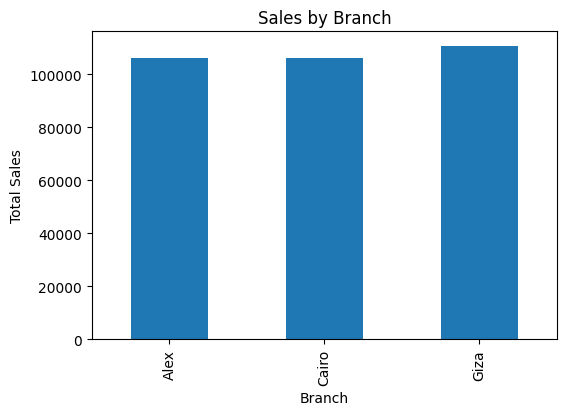

In [49]:
plt.figure(figsize=(6,4))

branch_sales.plot(kind="bar")

plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")

plt.show()

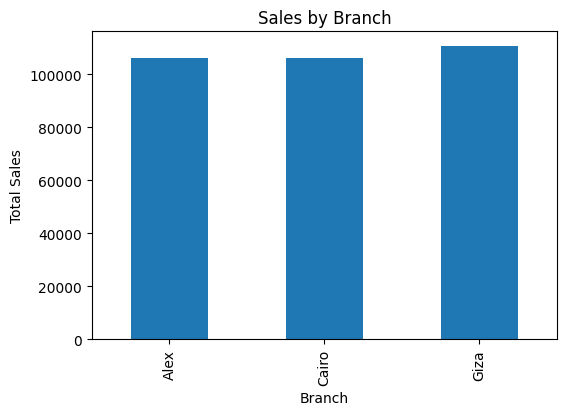

In [50]:
plt.figure(figsize=(6,4))

branch_sales.plot(kind="bar")

plt.title("Sales by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Sales")

plt.savefig("sales_by_branch.png")

plt.show()

## Chart 2: Payment Methods (Pie Chart)

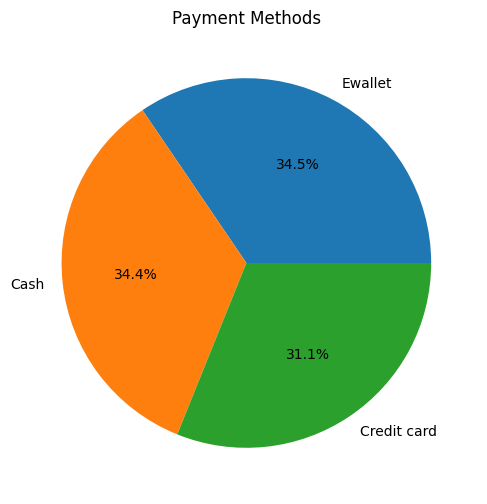

In [51]:
plt.figure(figsize=(6,6))

payment_method.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Methods")
plt.ylabel("")

plt.show()

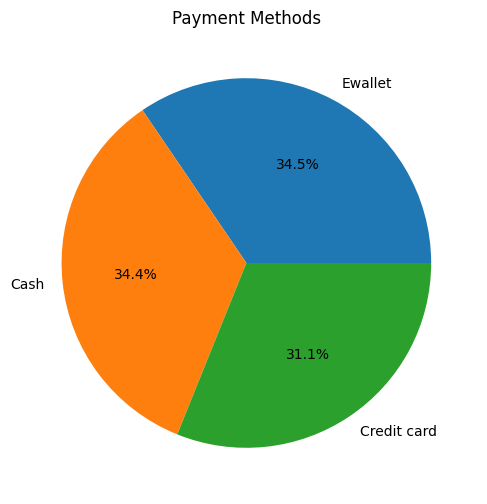

In [52]:
plt.figure(figsize=(6,6))

payment_method.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Payment Methods")
plt.ylabel("")

plt.savefig("payment_methods.png")

plt.show()

## Chart 3: Monthly Sales Trend (Line Chart)

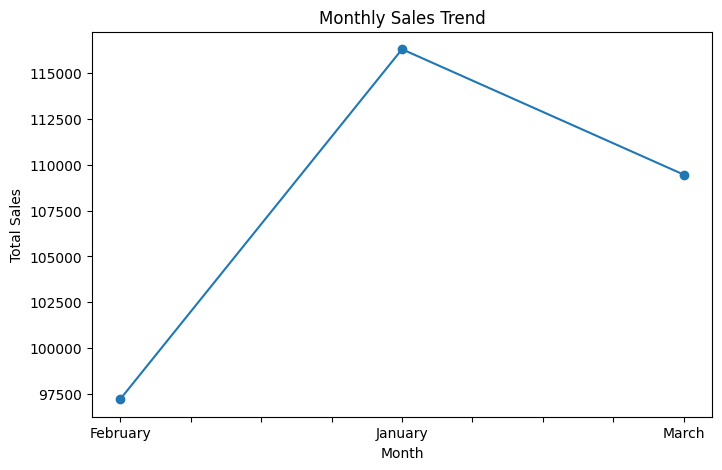

In [53]:
plt.figure(figsize=(8,5))

monthly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.savefig("monthly_sales.png")

plt.show()

## Chart 4: Customer Ratings Distribution (Histogram)

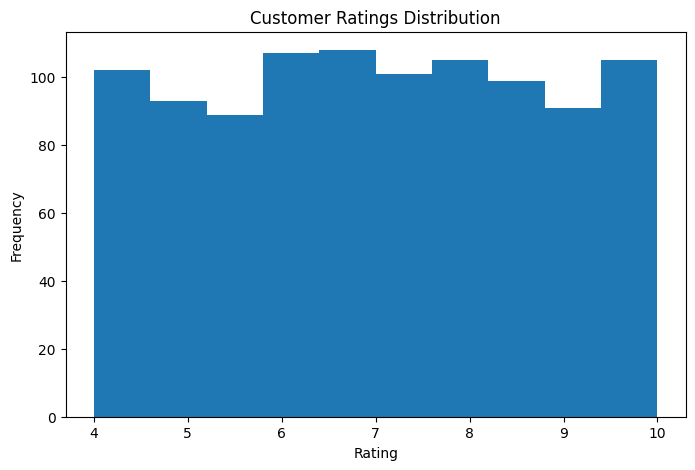

In [54]:
plt.figure(figsize=(8,5))

plt.hist(df["Rating"], bins=10)

plt.title("Customer Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.savefig("customer_ratings.png")

plt.show()

## Chart 5: Product Line Profit (Bar Chart)

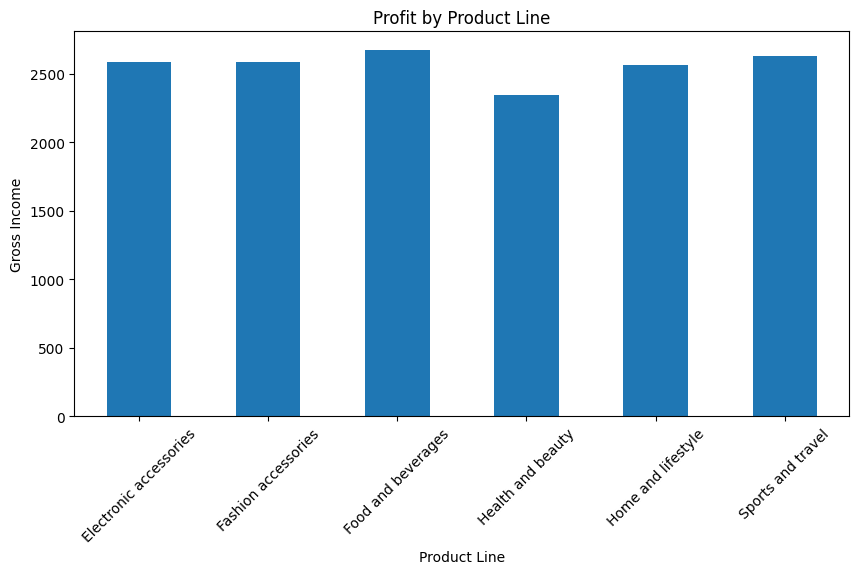

In [55]:
plt.figure(figsize=(10,5))

product_profit.plot(kind="bar")

plt.title("Profit by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Gross Income")

plt.xticks(rotation=45)

plt.savefig("product_profit.png")

plt.show()

In [56]:
import os

os.listdir()

['.config',
 'SuperMarket Analysis.csv',
 'monthly_sales.png',
 'customer_ratings.png',
 'product_profit.png',
 'SuperMarket Analysis (1).csv',
 'payment_methods.png',
 'SupermarketSales_cleaned.csv',
 'sales_by_branch.png',
 'sample_data']